# Session 6 — LLMs for Materials Science: Data Extraction, RAG, Agents, and an End-to-End Workflow

**Practical AI & Machine Learning for Materials Science · ACerS short course**

In this notebook you will:
1. **Extract structured data from text** with an LLM and *score* it against an answer key (vs. a regex baseline).
2. Build a minimal **retrieval-augmented generation (RAG)** pipeline that answers from your documents and cites them.
3. Give an LLM **tools** (your ML model from earlier sessions, a database lookup and a literature search) and watch an **agent** reason through a materials-selection task.
4. **Capstone:** connect the full pipeline: data → model → uncertainty → decision.

> **Key idea:** LLMs are most useful in materials science as the *glue* (reading text, calling tools, writing summaries) around the trustworthy, validated models you built in Sessions 2–5. They don't replace those models.

**Optional pre-watch** (from the [course YouTube playlist](https://www.youtube.com/playlist?list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0)):
- 📺 [33. Large Language Models in Materials Science](https://www.youtube.com/watch?v=sUl8ovLgK4Q&list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0)
- 📺 [Your GitHub Repo Is Now a Research Robot (Claude Code + GitHub Actions)](https://www.youtube.com/watch?v=U5sB19DLnOk&list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0)

*Want more?* [Materials Project Seminar: Materials informatics, moving beyond screening](https://www.youtube.com/watch?v=aDVmb3n4jQs&list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0)


## 0. Setup

This notebook uses Claude through the [Anthropic API](https://docs.anthropic.com/). **You need an API key for the LLM cells.** Without one, the notebook runs in **offline mode**: every non-LLM step (regex baseline, retrieval, tools, ML models, capstone ranking) still runs, and the LLM cells explain what they would do.

- **Colab:** click the 🔑 *Secrets* icon in the left sidebar, add `ANTHROPIC_API_KEY`, and enable notebook access.
- **Local:** `export ANTHROPIC_API_KEY=...` (macOS/Linux) or `setx ANTHROPIC_API_KEY ...` (Windows), then restart Jupyter.

In [1]:
# --- Setup: works locally and in Google Colab ---------------------------------
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/sp8rks/ACerS_AI_ML_Workshop"
if "google.colab" in sys.modules:
    ROOT = Path("/content/ACerS_AI_ML_Workshop")
    if not ROOT.exists():
        subprocess.run(["git", "clone", "-q", REPO_URL, str(ROOT)], check=True)
else:
    ROOT = Path.cwd().resolve()
    while not (ROOT / "workshop_utils").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("Workshop root:", ROOT)

Workshop root: C:\ACERS_AI_ML


In [2]:
try:
    import anthropic
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "anthropic"], check=True)
    import anthropic

import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from workshop_utils import (DATA_DIR, load_dataset, generate_features, featurize_formula,
                            element_fractions, parse_formula)

def get_api_key():
    key = os.environ.get("ANTHROPIC_API_KEY")
    if not key and "google.colab" in sys.modules:
        try:
            from google.colab import userdata
            key = userdata.get("ANTHROPIC_API_KEY")
        except Exception:
            key = None
    return key

API_KEY = get_api_key()
LIVE = bool(API_KEY)
client = anthropic.Anthropic(api_key=API_KEY) if LIVE else None
MODEL = "claude-opus-5-5"
print("LLM mode:", "LIVE ✅" if LIVE else "OFFLINE (no ANTHROPIC_API_KEY found): LLM cells will be skipped")

LLM mode: OFFLINE (no ANTHROPIC_API_KEY found): LLM cells will be skipped


A small helper for single LLM calls. Two details worth knowing:
- `output_config.format` with a **JSON schema** forces the reply to be valid JSON with exactly the fields we ask for. That is much more reliable than asking "please reply in JSON".
- `fallbacks="default"` lets the API retry on a fallback model if a request is declined by a safety classifier, so a workshop demo doesn't silently stop.

In [3]:
def ask_claude(prompt, system=None, schema=None, effort="low", max_tokens=8000):
    """One LLM call. Returns text, or parsed JSON when a schema is given."""
    output_config = {"effort": effort}
    if schema is not None:
        output_config["format"] = {"type": "json_schema", "schema": schema}
    kwargs = dict(model=MODEL, max_tokens=max_tokens, output_config=output_config,
                  messages=[{"role": "user", "content": prompt}],
                  betas=["server-side-fallback-2026-07-01"], fallbacks="default")
    if system:
        kwargs["system"] = system
    response = client.beta.messages.create(**kwargs)
    if response.stop_reason == "refusal":
        raise RuntimeError("The model declined this request.")
    text = "".join(block.text for block in response.content if block.type == "text")
    return json.loads(text) if schema is not None else text

## Part A — Extracting materials data from text

Most materials data is locked in papers as prose. Here is a small corpus of ten abstract-style paragraphs about ceramics.

⚠️ **These snippets are synthetic.** They were written for this workshop, with values in typical literature ranges, and come with an answer key so we can *measure* extraction quality.

In [4]:
corpus = json.loads((DATA_DIR / "ceramics_text_snippets.json").read_text(encoding="utf8"))
snippets = corpus["snippets"]
PROPERTY_UNITS = corpus["property_units"]
truth = pd.DataFrame([dict(id=s["id"], **r) for s in snippets for r in s["records"]])

print(snippets[0]["title"], "\n")
print(snippets[0]["text"])
print(f"\n{len(snippets)} snippets, {len(truth)} ground-truth property records")
truth.head(8)

Two-step sintering of 3 mol% yttria-stabilized tetragonal zirconia 

Commercial 3Y-TZP powders were consolidated by two-step sintering, with a first step at 1450 °C followed by a prolonged hold at 1150 °C. The resulting ceramics reached 99.2% of theoretical density while retaining an average grain size of 0.28 µm. Vickers hardness measured at 9.8 N was 12.5 GPa and the indentation fracture toughness was 5.2 MPa·m^1/2. Conventional single-step sintering produced comparable density only with substantial grain growth.

10 snippets, 32 ground-truth property records


,id,material,property,value
0,S01,3Y-TZP,sintering_temperature,1450.00
1,S01,3Y-TZP,relative_density,99.20
2,S01,3Y-TZP,grain_size,0.28
3,S01,3Y-TZP,hardness,12.50
4,S01,3Y-TZP,fracture_toughness,5.20
5,S02,Al2O3 + 0.05 wt% MgO,sintering_temperature,1550.00
6,S02,Al2O3 + 0.05 wt% MgO,grain_size,1.80
7,S02,Al2O3 + 0.05 wt% MgO,relative_density,99.60


### A1. Baseline: regular expressions
The traditional approach is to find "number + unit" patterns and guess the property from the unit.

In [5]:
UNIT_TO_PROPERTY = [
    (r"MPa\s*·?\s*m\^?1/2", "fracture_toughness"),
    (r"MPa", "flexural_strength"),
    (r"GPa", "hardness"),
    (r"W/\(m·K\)", "thermal_conductivity"),
    (r"eV", "band_gap"),
    (r"mS/cm", "ionic_conductivity"),
    (r"%", "relative_density"),
    (r"°C", "sintering_temperature"),
    (r"µm", "grain_size"),
]

def regex_extract(snippet):
    found = []
    for m in re.finditer(r"(\d+(?:\.\d+)?)\s*(MPa\s*·?\s*m\^?1/2|MPa|GPa|W/\(m·K\)|eV|mS/cm|%|°C|µm)", snippet["text"]):
        value, unit = float(m.group(1)), m.group(2)
        prop = next(p for pat, p in UNIT_TO_PROPERTY if re.fullmatch(pat, unit))
        found.append({"id": snippet["id"], "material": "?", "property": prop, "value": value})
    return found

regex_pred = pd.DataFrame([r for s in snippets for r in regex_extract(s)])
regex_pred.head(10)

,id,material,property,value
0,S01,?,sintering_temperature,1450.00
1,S01,?,sintering_temperature,1150.00
2,S01,?,relative_density,99.20
3,S01,?,grain_size,0.28
4,S01,?,hardness,12.50
5,S01,?,fracture_toughness,5.20
6,S02,?,sintering_temperature,1550.00
7,S02,?,grain_size,1.80
8,S02,?,relative_density,99.60
9,S02,?,flexural_strength,420.00


In [6]:
def score(pred, truth, rel_tol=0.02):
    """Precision/recall: a prediction is correct if (snippet, property) match and the value is within 2%."""
    pred = pred.copy()
    unmatched = truth.copy()
    correct = []
    for _, p in pred.iterrows():
        cand = unmatched[(unmatched.id == p["id"]) & (unmatched.property == p["property"]) &
                         (np.isclose(unmatched.value, p["value"], rtol=rel_tol))]
        correct.append(len(cand) > 0)
        if len(cand):
            unmatched = unmatched.drop(cand.index[0])
    pred["correct"] = correct
    tp = int(np.sum(correct))
    precision = tp / max(len(pred), 1)
    recall = tp / len(truth)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)
    return {"predicted": len(pred), "correct": tp, "precision": round(precision, 3),
            "recall": round(recall, 3), "F1": round(f1, 3)}, pred, unmatched

regex_scores, regex_checked, regex_missed = score(regex_pred, truth)
print("Regex baseline:", regex_scores)
regex_checked[~regex_checked.correct].head(8)

Regex baseline: {'predicted': 38, 'correct': 28, 'precision': 0.737, 'recall': 0.875, 'F1': 0.8}


,id,material,property,value,correct
1,S01,?,sintering_temperature,1150.0,False
18,S04,?,sintering_temperature,1500.0,False
19,S04,?,grain_size,45.0,False
20,S04,?,hardness,520.0,False
24,S05,?,sintering_temperature,25.0,False
25,S06,?,grain_size,10.0,False
27,S06,?,sintering_temperature,125.0,False
33,S08,?,hardness,479.0,False


**Why regex struggles:** "GPa" could be hardness *or* modulus, "°C" could be a sintering, oxidation or Curie temperature, the unit-less permittivity (4200) is invisible, and it has no idea *which material* a number belongs to.

### A2. LLM extraction with a JSON schema

In [7]:
EXTRACTION_SCHEMA = {
    "type": "object",
    "properties": {
        "records": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "material": {"type": "string", "description": "material or composition as written"},
                    "property": {"type": "string", "enum": list(PROPERTY_UNITS)},
                    "value": {"type": "number"},
                    "evidence": {"type": "string", "description": "short verbatim quote supporting the value"},
                },
                "required": ["material", "property", "value", "evidence"],
                "additionalProperties": False,
            },
        }
    },
    "required": ["records"],
    "additionalProperties": False,
}

EXTRACTION_SYSTEM = (
    "You extract quantitative materials-property data from ceramics papers for a database. "
    "Only record values that are explicitly reported as measured or achieved properties of a specific material. "
    "Convert each value to these units: " + json.dumps(PROPERTY_UNITS) + ". "
    "Record the main sintering/densification temperature as sintering_temperature, but not oxidation, annealing-hold or test temperatures. "
    "Hardness from any indentation method counts as hardness; Young's modulus counts as elastic_modulus; relative permittivity counts as dielectric_constant. "
    "If a paragraph reports no quantitative properties, return an empty list."
)

def llm_extract(snippet):
    out = ask_claude(f"Title: {snippet['title']}\n\n{snippet['text']}", system=EXTRACTION_SYSTEM,
                     schema=EXTRACTION_SCHEMA)
    return [{"id": snippet["id"], **r} for r in out["records"]]

if LIVE:
    llm_pred = pd.DataFrame([r for s in snippets for r in llm_extract(s)])
    llm_scores, llm_checked, llm_missed = score(llm_pred, truth)
    print("Regex baseline:", regex_scores)
    print("LLM extraction:", llm_scores)
    display(llm_checked[["id", "material", "property", "value", "correct", "evidence"]])
else:
    print("OFFLINE: skipping LLM extraction. With an API key, this cell sends each snippet to Claude with the\n"
          "JSON schema above and scores the result against the same answer key as the regex baseline.")

OFFLINE: skipping LLM extraction. With an API key, this cell sends each snippet to Claude with the
JSON schema above and scores the result against the same answer key as the regex baseline.

**Discuss:**
- Look at the LLM's *errors*. Are they ambiguous cases a human might also disagree on (e.g. is the 1150 °C second-step hold a "sintering temperature")?
- The `evidence` field lets a human verify each record quickly. **Always keep a provenance trail.**
- At scale, you would run this over thousands of PDFs, then **spot-check a random sample** to estimate precision before trusting the database.

✏️ **Exercise:** paste a paragraph from one of *your* papers into `my_text` below and extract from it.

In [8]:
my_text = """Paste a paragraph from your own work here."""
if LIVE and "Paste a paragraph" not in my_text:
    print(json.dumps(ask_claude(my_text, system=EXTRACTION_SYSTEM, schema=EXTRACTION_SCHEMA), indent=2))

## Part B — Retrieval-augmented generation (RAG)

LLMs can *sound* confident about things they don't know. RAG has two steps:
1. **Retrieve** the passages most relevant to a question from *your* documents.
2. **Generate** an answer *only* from those passages, with citations.

Real systems use neural embeddings and vector databases. Classic TF-IDF keyword retrieval is enough to show the idea and runs offline.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

docs = [f"{s['title']}. {s['text']}" for s in snippets]
vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), sublinear_tf=True).fit(docs)
doc_vectors = vectorizer.transform(docs)

def retrieve(query, k=3):
    sims = cosine_similarity(vectorizer.transform([query]), doc_vectors).ravel()
    top = np.argsort(sims)[::-1][:k]
    return [(snippets[i]["id"], round(float(sims[i]), 3), snippets[i]["title"]) for i in top]

question = "Which ceramic would be best for a heat-spreading substrate in power electronics, and why?"
for hit in retrieve(question):
    print(hit)

('S03', 0.233, 'High thermal conductivity silicon nitride for power-electronics substrates')
('S10', 0.0, 'Perspective: open challenges in cold sintering of ceramics')
('S09', 0.0, 'Phase-dependent photocatalysis in titania thin films')


In [10]:
RAG_SYSTEM = ("Answer using ONLY the provided context passages. Cite passage IDs in square brackets like [S03]. "
              "If the context does not contain the answer, say so plainly instead of guessing.")

def rag_answer(question, k=3):
    hits = retrieve(question, k)
    context = "\n\n".join(f"[{sid}] {next(s for s in snippets if s['id'] == sid)['text']}" for sid, _, _ in hits)
    prompt = f"Context passages:\n{context}\n\nQuestion: {question}"
    if not LIVE:
        return "OFFLINE. This is the prompt that would be sent:\n\n" + prompt
    return ask_claude(prompt, system=RAG_SYSTEM)

print(rag_answer(question))

OFFLINE. This is the prompt that would be sent:

Context passages:
[S03] β-Si3N4 ceramics containing Y2O3 and MgO sintering additives were gas-pressure sintered at 1900 °C for 12 h. Extended annealing reduced lattice oxygen and increased the thermal conductivity to 92 W/(m·K). The elongated-grain microstructure also delivered a fracture toughness of 7.1 MPa·m^1/2 and a flexural strength of 780 MPa, making the material attractive for substrates in high-power modules.

[S10] Cold sintering uses a transient liquid phase and uniaxial pressure to densify ceramics at temperatures far below conventional sintering. In this perspective we discuss open questions about the dissolution–precipitation mechanism, the role of the transient solvent chemistry, and the difficulty of scaling the process beyond small pellets. We argue that in situ characterization and shared benchmark datasets are needed before cold sintering can be widely adopted.

[S09] Sol-gel TiO2 films were annealed at 450 °C to obtai

⚠️ **Look at what was retrieved.** The best answer in the corpus is AlN (S07, 175 W/(m·K)), but keyword retrieval missed it: the question says *"substrate"* and *"heat-spreading"*, while the AlN passage says *"substrates"* and *"thermal conductivity"*. The LLM can only be as good as what retrieval hands it.

Production RAG systems use **semantic embeddings** (which know that "heat-spreading" ≈ "thermal conductivity"), hybrid keyword + vector search, and re-ranking. Watch what happens when we rephrase the query with the vocabulary of the documents:

In [11]:
for hit in retrieve("Which ceramic has the highest thermal conductivity for substrates?"):
    print(hit)

('S03', 0.305, 'High thermal conductivity silicon nitride for power-electronics substrates')
('S07', 0.219, 'Aluminum nitride substrates with low oxygen content')
('S05', 0.059, 'Garnet solid electrolytes with gallium substitution')


In [12]:
# The "I don't know" test: the corpus has nothing about this
print(rag_answer("What is the fracture toughness of the LLZO garnet electrolyte?"))

OFFLINE. This is the prompt that would be sent:

Context passages:
[S05] Ga-substituted Li7La3Zr2O12 (LLZO) pellets were prepared by solid-state reaction and sintered at 1100 °C in MgO crucibles. Gallium stabilized the cubic garnet phase and the pellets reached 96% relative density. Electrochemical impedance spectroscopy gave a total ionic conductivity of 1.3 mS/cm at 25 °C, with negligible electronic conductivity. Lithium loss during sintering was mitigated by a mother-powder bed.

[S03] β-Si3N4 ceramics containing Y2O3 and MgO sintering additives were gas-pressure sintered at 1900 °C for 12 h. Extended annealing reduced lattice oxygen and increased the thermal conductivity to 92 W/(m·K). The elongated-grain microstructure also delivered a fracture toughness of 7.1 MPa·m^1/2 and a flexural strength of 780 MPa, making the material attractive for substrates in high-power modules.

[S01] Commercial 3Y-TZP powders were consolidated by two-step sintering, with a first step at 1450 °C follo

**Discuss:** A good RAG system says *"the context doesn't say"* rather than inventing a plausible toughness value. Test this behavior before trusting any literature assistant.

## Part C — Agents: an LLM that uses *your* tools

An **agent** is an LLM in a loop: it decides which tool to call, reads the result, and repeats until it can answer.
The tools are ordinary Python functions. Here they wrap the work from earlier sessions:

| tool | what it does | from |
|---|---|---|
| `predict_bulk_modulus` | random-forest prediction **with uncertainty and a domain-of-applicability flag** | Sessions 2–4 |
| `lookup_dft_bulk_modulus` | exact DFT value if the composition is in our dataset | Session 1 |
| `search_literature` | TF-IDF retrieval over the text corpus | Part B |

First we train the model the tools will use.

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

bm = load_dataset("bulk_modulus")
X, y, formulae, _ = generate_features(bm, "oliynyk")
X = X.filter(like="avg_")
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=0).fit(X, y)
scaler = StandardScaler().fit(X)
nn = NearestNeighbors(n_neighbors=5).fit(scaler.transform(X))
train_dist = nn.kneighbors(scaler.transform(X), n_neighbors=6)[0][:, 1:].mean(axis=1)
DIST_CUTOFF = float(np.percentile(train_dist, 95))   # beyond this = "unlike the training data"

def canonical(formula):
    return tuple(sorted((el, round(x, 4)) for el, x in element_fractions(formula).items()))
DFT_LOOKUP = dict(zip(formulae.map(canonical), y))

Featurized 4873 formulas into 264 'oliynyk' features (skipped 32)


In [14]:
def predict_bulk_modulus(formulas):
    """Predict bulk modulus (GPa) with uncertainty for a list of formulas."""
    out = []
    for f in formulas:
        try:
            x = featurize_formula(f)[X.columns].to_frame().T
        except Exception as e:
            out.append({"formula": f, "error": f"could not parse formula: {e}"}); continue
        if x.isna().any(axis=None):
            out.append({"formula": f, "error": "contains elements without property data"}); continue
        trees = np.array([t.predict(x.to_numpy())[0] for t in rf.estimators_])
        dist = float(nn.kneighbors(scaler.transform(x))[0].mean())
        out.append({"formula": f, "predicted_GPa": round(float(trees.mean()), 1),
                    "uncertainty_GPa": round(float(trees.std()), 1),
                    "in_domain": dist <= DIST_CUTOFF})
    return out

def lookup_dft_bulk_modulus(formula):
    """Look up a DFT (AFLOW AEL) bulk modulus if this exact composition is in the dataset."""
    try:
        v = DFT_LOOKUP.get(canonical(formula))
    except Exception:
        return {"formula": formula, "error": "could not parse formula"}
    return {"formula": formula, "dft_bulk_modulus_GPa": None if v is None else round(float(v), 1)}

def search_literature(query):
    """Return the most relevant snippets from the literature corpus."""
    return [{"id": sid, "score": score_, "title": title,
             "text": next(s for s in snippets if s["id"] == sid)["text"]}
            for sid, score_, title in retrieve(query, k=2)]

# The tools work without any LLM:
predict_bulk_modulus(["HfC", "ZrB2", "Al2O3", "Li7La3Zr2O12"])

[{'formula': 'HfC',
  'predicted_GPa': 172.9,
  'uncertainty_GPa': 32.4,
  'in_domain': True},
 {'formula': 'ZrB2',
  'predicted_GPa': 235.7,
  'uncertainty_GPa': 17.7,
  'in_domain': True},
 {'formula': 'Al2O3',
  'predicted_GPa': 202.9,
  'uncertainty_GPa': 35.0,
  'in_domain': True},
 {'formula': 'Li7La3Zr2O12',
  'predicted_GPa': 86.0,
  'uncertainty_GPa': 29.3,
  'in_domain': True}]

Now we describe the tools to the model with JSON schemas. The **descriptions matter**: they are how the model decides which tool to use.

In [15]:
TOOLS = [
    {"name": "predict_bulk_modulus",
     "description": "Predict bulk modulus (GPa) for one or more chemical formulas with a random-forest model "
                    "trained on ~4,900 DFT values. Returns mean, uncertainty (std across trees) and in_domain "
                    "(False means the composition is unlike the training data, so the prediction is unreliable).",
     "input_schema": {"type": "object",
                      "properties": {"formulas": {"type": "array", "items": {"type": "string"}}},
                      "required": ["formulas"]}},
    {"name": "lookup_dft_bulk_modulus",
     "description": "Look up the DFT-computed bulk modulus (GPa) for an exact composition if it is in the "
                    "training database. Returns null if absent.",
     "input_schema": {"type": "object",
                      "properties": {"formula": {"type": "string"}},
                      "required": ["formula"]}},
    {"name": "search_literature",
     "description": "Search a small corpus of ceramics paper abstracts. Returns the two most relevant passages with IDs.",
     "input_schema": {"type": "object",
                      "properties": {"query": {"type": "string"}},
                      "required": ["query"]}},
]
TOOL_FUNCTIONS = {"predict_bulk_modulus": predict_bulk_modulus,
                  "lookup_dft_bulk_modulus": lookup_dft_bulk_modulus,
                  "search_literature": search_literature}

### The agent loop
This is the whole idea of an "agent" in about 30 lines: call the model, run any tools it asks for, send the results back, and repeat.

In [16]:
AGENT_SYSTEM = ("You are a materials-selection assistant for a ceramics R&D team. Use the tools to gather evidence. "
                "Prefer DFT values when available, treat predictions with in_domain=false or large uncertainty as "
                "unreliable, and cite literature passage IDs. Finish with a short ranked recommendation and the "
                "single most important caveat.")

def run_agent(task, max_turns=10, verbose=True):
    messages = [{"role": "user", "content": task}]
    for turn in range(max_turns):
        response = client.beta.messages.create(
            model=MODEL, max_tokens=16000, system=AGENT_SYSTEM, tools=TOOLS, messages=messages,
            output_config={"effort": "medium"},
            betas=["server-side-fallback-2026-07-01"], fallbacks="default")
        messages.append({"role": "assistant", "content": response.content})

        if response.stop_reason == "refusal":
            return "The model declined this request."
        if response.stop_reason != "tool_use":
            return "".join(b.text for b in response.content if b.type == "text")

        results = []
        for block in response.content:
            if block.type != "tool_use":
                continue
            if verbose:
                print(f"🔧 turn {turn + 1}: {block.name}({json.dumps(block.input)})")
            try:
                output = TOOL_FUNCTIONS[block.name](**block.input)
                results.append({"type": "tool_result", "tool_use_id": block.id,
                                "content": json.dumps(output, default=str)})
            except Exception as e:
                results.append({"type": "tool_result", "tool_use_id": block.id,
                                "content": f"Tool error: {e}", "is_error": True})
        messages.append({"role": "user", "content": results})   # all results in ONE message
    return "Stopped: reached max_turns."

In [17]:
TASK = ("We need a very stiff ceramic for a wear-resistant, high-temperature component. "
        "Candidates: HfC, ZrB2, Si3N4, Al2O3, TaC, (Hf0.2Zr0.2Ta0.2Nb0.2Ti0.2)C. "
        "Rank them by expected bulk modulus, say which numbers are reliable, and check the literature "
        "corpus for any supporting evidence about hardness or high-temperature behavior.")

if LIVE:
    print(run_agent(TASK))
else:
    print("OFFLINE: the agent needs an API key. Below is the same task as a fixed, hand-coded *workflow*.\n")
    candidates = ["HfC", "ZrB2", "Si3N4", "Al2O3", "TaC", "(Hf0.2Zr0.2Ta0.2Nb0.2Ti0.2)C"]
    table = pd.DataFrame(predict_bulk_modulus(candidates))
    table["dft_GPa"] = [lookup_dft_bulk_modulus(f)["dft_bulk_modulus_GPa"] for f in candidates]
    print(table.sort_values("predicted_GPa", ascending=False).to_string(index=False))
    print("\nLiterature hits:", [h["id"] for h in search_literature("hardness high temperature carbide boride")])

OFFLINE: the agent needs an API key. Below is the same task as a fixed, hand-coded *workflow*.



                     formula  predicted_GPa  uncertainty_GPa  in_domain  dft_GPa
                         TaC          299.4             41.7       True    315.4
                        ZrB2          235.7             17.7       True    238.2
(Hf0.2Zr0.2Ta0.2Nb0.2Ti0.2)C          217.5             44.8       True      NaN
                       Si3N4          216.1             55.7       True    234.4
                       Al2O3          202.9             35.0       True    230.7
                         HfC          172.9             32.4       True    158.3

Literature hits: ['S04', 'S08']


**Workflow vs. agent:** in the offline version *you* decided the steps in code. In the agent version *the model* decided which tools to call and in what order.
- Use **workflows** when the steps are known and fixed. They are cheaper, faster, more predictable and easier to validate.
- Use **agents** when the path depends on what is found along the way (open-ended questions, messy data, many possible tools).
- Either way, the model's answer is only as good as the **tools** it calls. That is why Sessions 2–5 matter.

## Part D — Capstone: data → model → decision

**Scenario:** your team can synthesize **3** new transition-metal carbides, nitrides or borides this quarter and wants the stiffest ones. You have a model (Sessions 2–4), uncertainty (Session 4) and a selection strategy (Session 5).

1. **Generate** a candidate space (binary and equimolar mixed-metal compounds).
2. **Predict** with uncertainty and a domain-of-applicability check.
3. **Decide** using an upper-confidence-bound score and remove anything already known or out of domain.
4. **Communicate:** have the LLM draft a decision memo, which a human then reviews.

In [18]:
from itertools import combinations

metals = ["Ti", "Zr", "Hf", "V", "Nb", "Ta", "Cr", "Mo", "W"]
anions = {"C": "carbide", "N": "nitride", "B2": "diboride"}
candidates = []
for a in anions:
    candidates += [f"{m}{a}" for m in metals]
    candidates += [f"({m1}0.5{m2}0.5){a}" for m1, m2 in combinations(metals, 2)]
print(len(candidates), "candidate compositions, e.g.", candidates[:3], candidates[-2:])

135 candidate compositions, e.g. ['TiC', 'ZrC', 'HfC'] ['(Cr0.5W0.5)B2', '(Mo0.5W0.5)B2']


In [19]:
pred = pd.DataFrame(predict_bulk_modulus(candidates)).dropna(subset=["predicted_GPa"])
pred["known_DFT_GPa"] = [lookup_dft_bulk_modulus(f)["dft_bulk_modulus_GPa"] for f in pred.formula]
pred["family"] = [next(v for k, v in anions.items() if f.endswith(k)) for f in pred.formula]

KAPPA = 1.0   # exploration weight (Session 5)
pred["UCB"] = pred.predicted_GPa + KAPPA * pred.uncertainty_GPa

shortlist = (pred[pred.in_domain & pred.known_DFT_GPa.isna()]
             .sort_values("UCB", ascending=False).head(3))
print(f"{(~pred.in_domain).sum()} candidates flagged out-of-domain; "
      f"{pred.known_DFT_GPa.notna().sum()} already in the database.\n")
shortlist

0 candidates flagged out-of-domain; 24 already in the database.



,formula,predicted_GPa,uncertainty_GPa,in_domain,known_DFT_GPa,family,UCB
53,WN,341.3,40.2,True,NaN,nitride,381.5
34,(V0.5W0.5)C,318.8,51.2,True,NaN,carbide,370.0
41,(Ta0.5W0.5)C,316.4,52.8,True,NaN,carbide,369.2


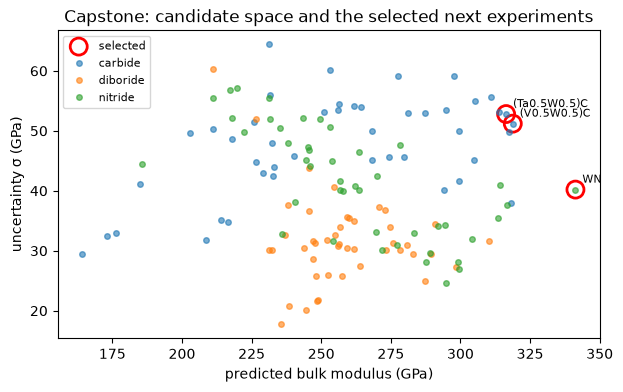

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
for fam, sub in pred.groupby("family"):
    ax.errorbar(sub.predicted_GPa, sub.uncertainty_GPa, fmt="o", ms=4, alpha=0.6, label=fam)
ax.scatter(shortlist.predicted_GPa, shortlist.uncertainty_GPa, s=150, facecolors="none",
           edgecolors="red", lw=2, label="selected")
for _, r in shortlist.iterrows():
    ax.annotate(r.formula, (r.predicted_GPa, r.uncertainty_GPa), xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_xlabel("predicted bulk modulus (GPa)"); ax.set_ylabel("uncertainty σ (GPa)")
ax.set_title("Capstone: candidate space and the selected next experiments")
ax.legend(fontsize=8)
plt.show()

In [21]:
if LIVE:
    memo_prompt = (
        "Draft a half-page decision memo for a ceramics R&D manager. Context: we screened "
        f"{len(pred)} transition-metal carbide/nitride/diboride compositions with a random-forest model "
        "(test MAE about 12 GPa on bulk modulus; trained on DFT data) and selected the top 3 by an "
        "upper-confidence-bound score, excluding already-known and out-of-domain compositions.\n\n"
        f"Shortlist:\n{shortlist.to_string(index=False)}\n\n"
        "Include: the recommendation, why each was chosen, the main risks (model limitations, DFT vs. "
        "experiment, synthesis feasibility), and a concrete validation plan. Be concise and do not invent data.")
    print(ask_claude(memo_prompt, effort="medium"))
else:
    print("OFFLINE: with an API key, Claude drafts a decision memo from the shortlist table above.")

OFFLINE: with an API key, Claude drafts a decision memo from the shortlist table above.


### Reflection: what made this pipeline trustworthy (or not)?
- ✅ The *numbers* came from a validated model with uncertainty, not from the LLM.
- ✅ Out-of-domain candidates were filtered out explicitly.
- ✅ Known compounds were excluded, so we spend experiments on new information.
- ⚠️ Bulk modulus from DFT ≠ the hardness or wear resistance you actually need. Is it the right **proxy**?
- ⚠️ Mixed-metal compositions may not form single-phase solid solutions. That needs a *stability* model or a phase-diagram check.
- ⚠️ An LLM-written memo can sound authoritative. **A human signs off.**

## Hands-on exercises
1. Change `KAPPA` to 0 and to 3. How does the shortlist change, and which would you defend to your manager?
2. Add a tool `predict_is_metal(formula)` using the band-gap classifier from Session 3, and ask the agent for an **insulating**, stiff ceramic.
3. Ask the agent a question it *cannot* answer with its tools (e.g. "what is the cost per kg?"). Does it admit it?
4. **Your pipeline:** sketch the data → model → decision loop for the problem you framed in Session 1. Which steps could an LLM help with, and which must stay validated models or human judgment?

---
**Go deeper:** full course `worked_examples/LLM Data Extraction` (Hugging Face open models for extraction) and `worked_examples/agents` (LangGraph materials-selection tutorial) ·
Anthropic docs: [tool use](https://docs.anthropic.com/en/docs/agents-and-tools/tool-use/overview), [structured outputs](https://docs.anthropic.com/en/docs/build-with-claude/structured-outputs) ·
open models via [Ollama](https://ollama.com/) or [Hugging Face](https://huggingface.co/) if your data can't leave your network.